# Offline Ternary Hex Animation from Saved Runs

This notebook loads saved run artifacts and builds ternary hex-density animations without rerunning training.

Expected run payloads:
- dict with `data` containing snapshot list, or
- raw snapshot list

Snapshot format expected from `SelectionMethod.helper`: each snapshot has keys like `yh` / `yvh` (log-probs).

In [17]:
from pathlib import Path
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.patches import Polygon
from IPython.display import HTML

In [18]:
def load_run_payload(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return torch.load(path, map_location='cpu', weights_only=False)

def get_ts(bs=320, epochs=200, save_init=5, save_freq=4, len_data=50000):
    t = 0
    ts = [t]
    n_batches = len_data // bs
    for epoch in range(epochs):
        for i in range(n_batches):
            t += 1
            if epoch < save_init and i % (n_batches // save_freq) == 0:
                ts.append(t)

        if save_init <= epoch <= 25:
            ts.append(t)
        elif 25 < epoch <= 65 and epoch % 4 == 0:
            ts.append(t)
        elif epoch > 65 and epoch % 15 == 0 or (epoch == epochs - 1):
            ts.append(t)
    return ts

def extract_snapshots(payload):
    if isinstance(payload, dict) and 'data' in payload:
        snapshots = payload['data']
    else:
        snapshots = payload
    if not isinstance(snapshots, (list, tuple)):
        raise ValueError('Could not find snapshot list in run artifact.')
    if len(snapshots) == 0:
        raise ValueError('Snapshot list is empty.')
    return list(snapshots)


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def snapshot_to_ternary(snapshot, split_key='yh', ternary_mode='first3'):
    if split_key not in snapshot:
        raise KeyError(f"Snapshot missing key '{split_key}'. Available: {list(snapshot.keys())}")

    log_probs = _to_numpy(snapshot[split_key])
    probs = np.exp(log_probs)

    if probs.ndim != 2:
        raise ValueError(f'Expected 2D probabilities, got shape {probs.shape}')

    c = probs.shape[1]
    if c >= 3:
        if ternary_mode == 'first3':
            tri = probs[:, :3]
        elif ternary_mode == 'top3':
            top3_idx = np.argsort(probs, axis=1)[:, -3:]
            tri = np.take_along_axis(probs, top3_idx, axis=1)
        else:
            raise ValueError('ternary_mode must be first3 or top3')
    elif c == 2:
        third = np.clip(1.0 - probs.sum(axis=1, keepdims=True), 0.0, 1.0)
        tri = np.concatenate([probs, third], axis=1)
    else:
        raise ValueError(f'Need >=2 classes to project to ternary, got {c}')

    denom = np.clip(tri.sum(axis=1, keepdims=True), 1e-12, None)
    return tri / denom

def barycentric_to_cartesian(bary):
    v0 = np.array([0.0, 0.0])
    v1 = np.array([1.0, 0.0])
    v2 = np.array([0.5, math.sqrt(3) / 2.0])
    return bary[:,0:1]*v0 + bary[:,1:2]*v1 + bary[:,2:3]*v2


def load_true_labels_for_run(run_path, dataset, split_key='yh'):
    labels_path = Path(f'/home/lgreen/projects/Online_BS/labels/{dataset}.p')
    if not labels_path.exists():
        raise FileNotFoundError(f'Missing label file: {labels_path}')

    labels_payload = torch.load(labels_path, map_location='cpu', weights_only=False)
    if not isinstance(labels_payload, dict):
        raise ValueError(f'Unexpected label payload format in {labels_path}')

    split = 'train' if split_key == 'yh' else 'val'
    if split not in labels_payload:
        raise KeyError(f"Label file missing split '{split}'. Available: {list(labels_payload.keys())}")

    labels = np.asarray(labels_payload[split]).astype(int)
    return labels, labels_path

In [19]:
def make_ternary_hex_animation(
    snapshots,
    ts,
    title,
    split_key='yh',
    ternary_mode='first3',
    class_index=None,
    true_labels=None,
    gridsize=24,
    cmap='viridis',
    norm='sqrt',
    interval=150,
    corner_labels=('Class 0', 'Class 1', 'Class 2'),
    save_mp4=False,
    save_png_frames=False,
    png_dir=None,
    frame_prefix='frame',
    out_name='ternary_hex_offline'
):
    y_max = math.sqrt(3) / 2.0

    bary_frames = [snapshot_to_ternary(s, split_key=split_key, ternary_mode=ternary_mode) for s in snapshots]

    if class_index is not None:
        cls = int(class_index)
        if cls < 0 or cls > 2:
            raise ValueError('class_index must be one of {0,1,2} or None')
        if true_labels is None:
            raise ValueError('true_labels is required when class_index is set')

        labels_arr = np.asarray(true_labels).astype(int)
        filtered = []
        class_counts = []
        for b in bary_frames:
            if labels_arr.shape[0] != b.shape[0]:
                raise ValueError(
                    f'true_labels length ({labels_arr.shape[0]}) does not match snapshot rows ({b.shape[0]})'
                )
            keep = labels_arr == cls
            bf = b[keep]
            class_counts.append(int(bf.shape[0]))
            if bf.shape[0] == 0:
                bf = np.array([[1/3, 1/3, 1/3]], dtype=float)
            filtered.append(bf)
        bary_frames = filtered
        vmax = float(max(class_counts) if len(class_counts) > 0 else 1)
    else:
        frame_sizes = [int(b.shape[0]) for b in bary_frames]
        vmax = float(max(frame_sizes) if len(frame_sizes) > 0 else 1)

    vmax = max(vmax, 1.0)
    cart_frames = [barycentric_to_cartesian(b) for b in bary_frames]

    norm_name = str(norm).lower()
    is_log_norm = False
    if norm_name == 'linear':
        density_norm = mcolors.Normalize(vmin=0.0, vmax=vmax, clip=True)
    elif norm_name == 'log':
        # LogNorm cannot accept zero; use 1 as the minimum displayed color value
        # and show a separate '0' label below the colorbar. This preserves
        # logarithmic spacing for positive integer densities while allowing a
        # visible indicator for zero counts.
        is_log_norm = True
        density_norm = mcolors.LogNorm(vmin=1, vmax=max(vmax, 1.0), clip=True)
    else:
        density_norm = mcolors.PowerNorm(gamma=0.5, vmin=0.0, vmax=vmax, clip=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    verts = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, y_max], [0.0, 0.0]])
    ax.plot(verts[:, 0], verts[:, 1], color='black', linewidth=1.2, zorder=5)

    left_label, right_label, top_label = corner_labels
    ax.text(0.0, -0.025, left_label, ha='left', va='top', fontsize=10)
    ax.text(1.0, -0.025, right_label, ha='right', va='top', fontsize=10)
    ax.text(0.5, y_max + 0.006, top_label, ha='center', va='bottom', fontsize=10)

    mid_bary = np.array([[0.0, 0.5, 0.5], [0.5, 0.0, 0.5], [0.5, 0.5, 0.0]])
    centroid_bary = np.array([[1/3, 1/3, 1/3]])
    mid_cart = barycentric_to_cartesian(mid_bary)
    centroid_cart = barycentric_to_cartesian(centroid_bary)[0]
    for m in mid_cart:
        ax.plot([m[0], centroid_cart[0]], [m[1], centroid_cart[1]], color='white', linewidth=1.2, zorder=7)

    clip_poly = Polygon(verts[:-1], closed=True, transform=ax.transData)

    hb = ax.hexbin(
        cart_frames[0][:, 0],
        cart_frames[0][:, 1],
        gridsize=gridsize,
        cmap=cmap,
        norm=density_norm,
        mincnt=0,
        extent=(0.0, 1.0, 0.0, y_max),
        linewidths=0.0,
        alpha=0.95,
        zorder=2,
    )
    hb.set_clip_path(clip_poly)
    cbar = fig.colorbar(hb, ax=ax, label='Point density')
    if is_log_norm:
        import matplotlib.ticker as mticker

        def _log_ticks(maxval):
            # Build a set of integer ticks spaced roughly logarithmically:
            # values like 1,2,5,10,20,50,... up to maxval
            ticks = []
            maxval = max(1, int(maxval))
            max_exp = int(math.log10(maxval)) if maxval > 0 else 0
            for exp in range(0, max_exp + 1):
                for m in (1, 2, 5):
                    v = m * (10 ** exp)
                    if v <= maxval:
                        ticks.append(int(v))
            ticks = sorted(set(ticks))
            if ticks[-1] != int(maxval):
                ticks.append(int(maxval))
            return ticks

        ticks = _log_ticks(int(max(vmax, 1)))
        cbar.set_ticks(ticks)
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
        # Add a '0' label below the colorbar to indicate zero-count bins.
        cbar.ax.text(0.5, -0.03, '0', transform=cbar.ax.transAxes, ha='center', va='top')

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, y_max + 0.05)

    def frame_title(i):
        cls_txt = 'all' if class_index is None else corner_labels[class_index]
        return f'{title} ({cls_txt}) - step {ts[i]}'

    def draw_frame(i):
        nonlocal hb
        if hb is not None:
            hb.remove()
        cur = cart_frames[i]
        hb = ax.hexbin(
            cur[:, 0],
            cur[:, 1],
            gridsize=gridsize,
            cmap=cmap,
            norm=density_norm,
            mincnt=0,
            extent=(0.0, 1.0, 0.0, y_max),
            linewidths=0.0,
            alpha=0.95,
            zorder=2,
        )
        hb.set_clip_path(clip_poly)
        cbar.update_normal(hb)
        ax.set_title(frame_title(i), fontsize=14, pad=22)
        return hb

    def update(i):
        draw_frame(i)
        return (hb,)

    draw_frame(0)

    if save_png_frames:
        png_root = Path(png_dir) if png_dir is not None else Path(out_name).parent / f'{Path(out_name).stem}_frames'
        png_root.mkdir(parents=True, exist_ok=True)
        for i in range(len(cart_frames)):
            draw_frame(i)
            fig.savefig(png_root / f'{frame_prefix}_{i:04d}.png', dpi=150, bbox_inches='tight')
        draw_frame(0)
        print('Saved PNG frames to', png_root.resolve())

    ani = FuncAnimation(fig, update, frames=len(cart_frames), interval=interval, blit=False)

    if save_mp4:
        out_path = Path(out_name).with_suffix('.mp4')
        out_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            import imageio_ffmpeg as iioff
            plt.rcParams['animation.ffmpeg_path'] = iioff.get_ffmpeg_exe()
        except Exception:
            pass
        writer = FFMpegWriter(fps=max(1, int(1000 / max(interval, 1))), bitrate=1800)
        ani.save(str(out_path), writer=writer, dpi=150)
        print('Saved', out_path.resolve())

    return fig, ani

In [20]:
# Find candidate run files
results_root = Path('results')
candidates = sorted(results_root.rglob('*.p')) + sorted(results_root.rglob('*.pt')) + sorted(results_root.rglob('*.pth'))
for p in candidates[:40]:
    print(p)
print(f'Found {len(candidates)} candidate files')

Found 0 candidate files


Loaded snapshots: 87
Loaded true labels from: /home/lgreen/projects/Online_BS/labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/lgreen/projects/Online_BS/ternary/pngs/CIFAR3/Bayesian_seed1
Saved /home/lgreen/projects/Online_BS/ternary/animations/CIFAR3/Bayesian_seed1.mp4


/home/lgreen/projects/Online_BS/.venv/lib/python3.10/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


Loaded snapshots: 87
Loaded true labels from: /home/lgreen/projects/Online_BS/labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/lgreen/projects/Online_BS/ternary/pngs/CIFAR3/TrainLoss_seed1
Saved /home/lgreen/projects/Online_BS/ternary/animations/CIFAR3/TrainLoss_seed1.mp4
Loaded snapshots: 87
Loaded true labels from: /home/lgreen/projects/Online_BS/labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/lgreen/projects/Online_BS/ternary/pngs/CIFAR3/RhoLoss_seed1
Saved /home/lgreen/projects/Online_BS/ternary/animations/CIFAR3/RhoLoss_seed1.mp4
Loaded snapshots: 87
Loaded true labels from: /home/lgreen/projects/Online_BS/labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /home/lgreen/projects/Online_BS/ternary/pngs/CIFAR3/DivBS_seed1
Saved /home/lgreen/projects/Online_BS/ternary/animations/CIFAR3/DivBS_seed1.mp4
Loaded snapshots: 87
Loaded true labels from: /home/lgreen/projects/Online_BS/labels/CIFAR3.p
True label count: 15000
Saved PNG frames to /hom

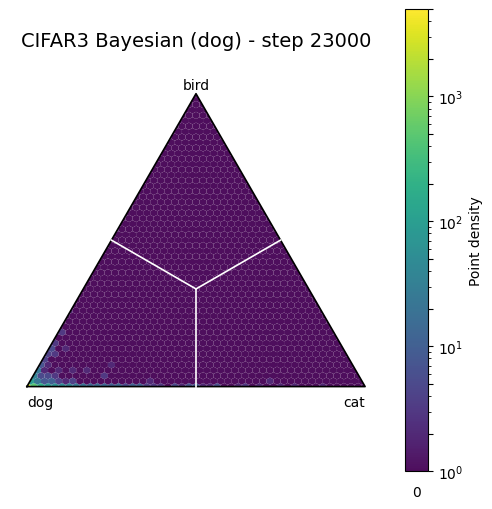

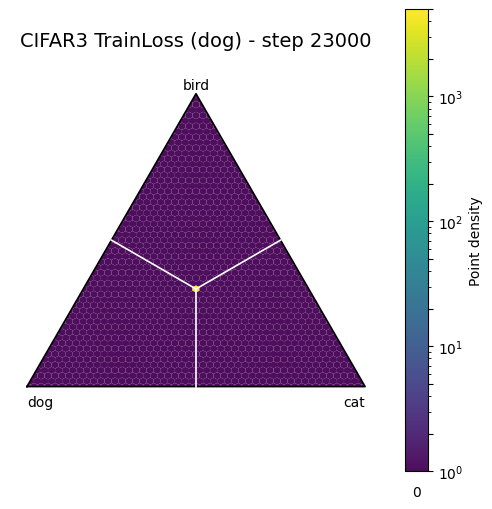

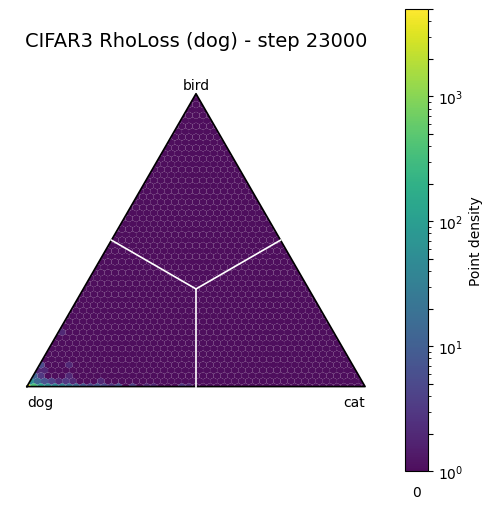

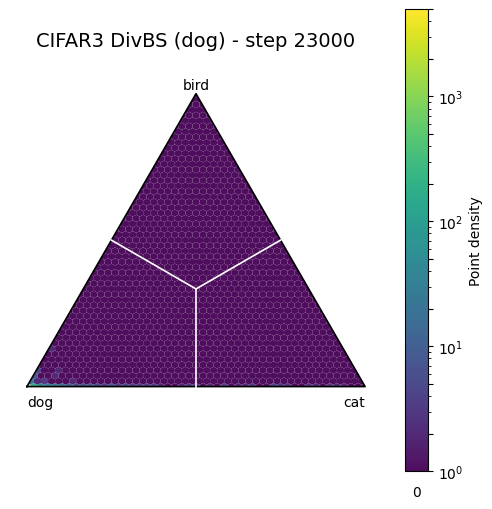

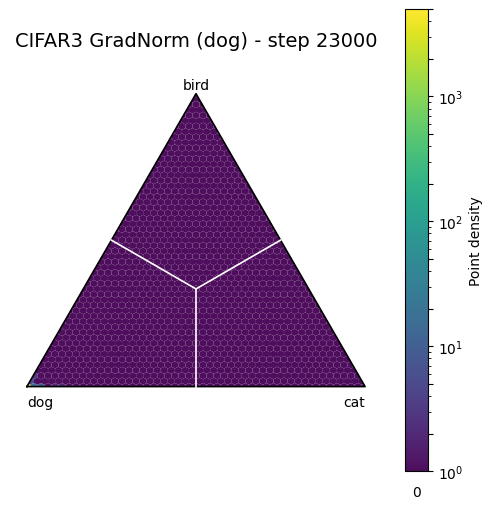

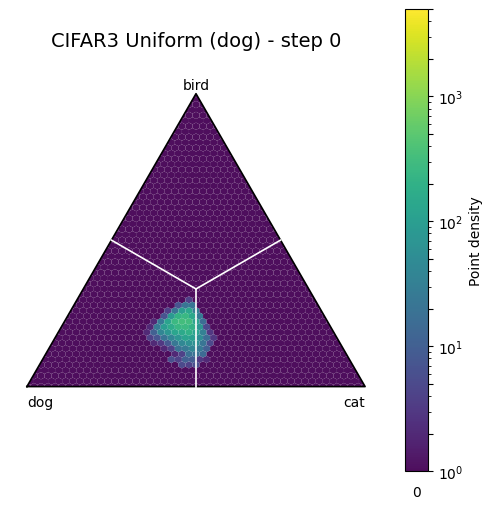

In [21]:
dataset = 'CIFAR3'

for method in ["Bayesian", "TrainLoss", "RhoLoss", "DivBS", "GradNorm", "Uniform"]:

    anim_out_root = Path(f'/home/lgreen/projects/Online_BS/ternary/animations/{dataset}/{method}_seed1')
    png_out_root = Path(f'/home/lgreen/projects/Online_BS/ternary/pngs/{dataset}/{method}_seed1')
    run_path = '/home/lgreen/projects/Online_BS/snapshots/CIFAR3/{"bsel":"' + method + '","seed":1,"model":"ResNet_torchvision","opt":"adamw","bs":320,"ratio":0.1,"lr":0.001,"wd":0.01}.p'

    # ts = get_ts(bs=50, epochs=25, save_init=5, save_freq=4, len_data=1000)
    ts = get_ts(epochs=500, len_data=15000)
    split_key = 'yh'  # 'yh' for train snapshots, 'yvh' for validation snapshots

    if run_path is None:
        print('Set run_path first')
    else:
        payload = load_run_payload(run_path)
        snapshots = extract_snapshots(payload)
        print('Loaded snapshots:', len(snapshots))

        true_labels = None
        labels_path = None
        try:
            true_labels, labels_path = load_true_labels_for_run(run_path, dataset, split_key=split_key)
            print('Loaded true labels from:', labels_path)
            print('True label count:', len(true_labels))
        except Exception as e:
            print('Could not load true labels:', e)
            print('If class_index is set, a matching labels_{dataset}.p file is required.')

    if run_path is not None:
        fig, ani = make_ternary_hex_animation(
            snapshots=snapshots,
            ts=ts,
            title=f'{dataset} {method}',
            split_key=split_key,
            ternary_mode='first3',
            class_index=0,
            true_labels=true_labels,
            gridsize=48,
            cmap='viridis',
            norm='log',
            interval=200,
            corner_labels=('dog', 'cat', 'bird'),
            save_mp4=True,
            save_png_frames=True,
            png_dir=png_out_root,
            out_name=str(anim_out_root)
        )
        HTML(ani.to_jshtml())

In [22]:
test_snapshots = [
    {'yh': np.log(np.array([[0.7, 0.2, 0.1], [0.2, 0.6, 0.2], [0.15, 0.25, 0.6]]))},
    {'yh': np.log(np.array([[0.6, 0.3, 0.1], [0.25, 0.5, 0.25], [0.2, 0.2, 0.6]]))},
]

fig, ani = make_ternary_hex_animation(
    snapshots=test_snapshots,
    ts=[0, 1],
    title='png export smoke test',
    save_mp4=False,
    save_png_frames=True,
    png_dir=Path('/home/lgreen/projects/Online_BS/runs/test_hex_png_frames'),
    corner_labels=('A', 'B', 'C'),
)

plt.close(fig)

Saved PNG frames to /home/lgreen/projects/Online_BS/runs/test_hex_png_frames
